# FreshRAG Temporal-Aware Generation Stage Analysis
## How Does Staleness in Context Affect LLM Generation Efficiency?

This notebook analyzes the generation stage (Stage 4) results across four staleness conditions:
- **Fresh (0%)**: All documents are current
- **Stale-10%**: 10% of answer-bearing docs replaced with outdated versions
- **Stale-30%**: 30% replaced
- **Stale-50%**: 50% replaced

Evaluation metrics:
- **Input tokens**: Prompt token count reported by the API
- **Output tokens**: Completion token count reported by the API
- **Generation latency (ms)**: Wall-clock time per API call
- **API cost estimate (USD)**: Based on token counts and model pricing
- **Response length (words)**: Word count of the generated answer
- **Answer correctness (ROUGE-L F1)**: Longest common subsequence overlap with ground truth
- **Hallucination rate**: Fraction of answers flagged as hallucinated by NLI entailment check

Also examines how upstream context quality (contradiction density, redundancy, stale token ratio) correlates with generation behavior.

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Style setup ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'fresh': '#2ecc71',
    'stale_10': '#f1c40f',
    'stale_30': '#e67e22',
    'stale_50': '#e74c3c',
}
CONDITION_LABELS = {
    'fresh': 'Fresh (0%)',
    'stale_10': 'Stale 10%',
    'stale_30': 'Stale 30%',
    'stale_50': 'Stale 50%',
}
CONDITIONS = ['fresh', 'stale_10', 'stale_30', 'stale_50']
STALENESS_PCTS = [0, 10, 30, 50]

DOMAINS = ['covidqa', 'cuad', 'expertqa', 'finqa', 'techqa']
DOMAIN_LABELS = {
    'covidqa': 'Healthcare',
    'cuad': 'Legal',
    'expertqa': 'Expert/Cross-domain',
    'finqa': 'Finance',
    'techqa': 'SaaS/IT',
}

print('Setup complete.')

import os
FIGURES_DIR = '../figures_temporal'
os.makedirs(FIGURES_DIR, exist_ok=True)


Setup complete.


In [4]:
# ── Load data ──
RESULTS_PATH = '../freshrag_experiment/results_temporal/generation_temporal_results_aggregated.json'
DETAILED_PATH = '../freshrag_experiment/results/generation_results_detailed.jsonl'

with open(RESULTS_PATH) as f:
    data = json.load(f)

detailed = []
with open(DETAILED_PATH) as f:
    for line in f:
        if line.strip():
            detailed.append(json.loads(line))

df = pd.DataFrame(detailed)

# Determine which model was used
model_name = df['model'].iloc[0] if 'model' in df.columns else 'unknown'

print(f'Sections: {list(data.keys())}')
print(f'Conditions: {list(data["overall"].keys())}')
print(f'Queries per condition: {data["overall"]["fresh"]["n"]}')
print(f'Total detailed records: {len(df)}')
print(f'Model: {model_name}')

Sections: ['overall', 'by_time_sensitivity', 'by_domain']
Conditions: ['fresh', 'stale_10', 'stale_30', 'stale_50']
Queries per condition: 289
Total detailed records: 1156
Model: gemini-2.5-flash


## 1. Overall Generation Metrics
Overview table of all metrics across staleness conditions.

In [5]:
# ── Build overview dataframe ──
overview_rows = []
for cond in CONDITIONS:
    d = data['overall'][cond]
    overview_rows.append({
        'Condition': CONDITION_LABELS[cond],
        'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
        'Input Tokens (mean)': d['input_tokens_mean'],
        'Output Tokens (mean)': d['output_tokens_mean'],
        'Latency ms (mean)': d['latency_ms_mean'],
        'Response Words (mean)': d['response_length_words_mean'],
        'Answer Correctness': d['answer_correctness_mean'],
        'Hallucination Rate': d['is_hallucination_mean'],
        'Cost/Query USD (mean)': d['cost_usd_mean'],
        'Total Cost USD': d['cost_usd_sum'],
        'n': d['n'],
    })

df_overview = pd.DataFrame(overview_rows)
df_overview.set_index('Condition', inplace=True)
df_overview.style.format({
    'Input Tokens (mean)': '{:.1f}',
    'Output Tokens (mean)': '{:.1f}',
    'Latency ms (mean)': '{:.1f}',
    'Response Words (mean)': '{:.1f}',
    'Answer Correctness': '{:.4f}',
    'Hallucination Rate': '{:.4f}',
    'Cost/Query USD (mean)': '{:.6f}',
    'Total Cost USD': '{:.4f}',
    'n': '{:.0f}',
}).background_gradient(cmap='RdYlGn_r', subset=['Output Tokens (mean)', 'Latency ms (mean)', 'Total Cost USD', 'Hallucination Rate'])\
 .background_gradient(cmap='RdYlGn', subset=['Answer Correctness'])

,Staleness %,Input Tokens (mean),Output Tokens (mean),Latency ms (mean),Response Words (mean),Answer Correctness,Hallucination Rate,Cost/Query USD (mean),Total Cost USD,n
Condition,,,,,,,,,,
Fresh (0%),0,3265.2,77.6,5119.2,52.8,0.3079,0.9377,0.000536,0.1550,289
Stale 10%,10,3261.1,82.0,4995.1,55.9,0.3080,0.9377,0.000538,0.1556,289
Stale 30%,30,3263.8,77.0,5320.5,53.2,0.3074,0.9481,0.000536,0.1548,289
Stale 50%,50,3255.0,74.4,5337.4,51.5,0.2918,0.9516,0.000533,0.1540,289


## 2. Token Usage & Generation Latency
How do input/output tokens and latency change with staleness?

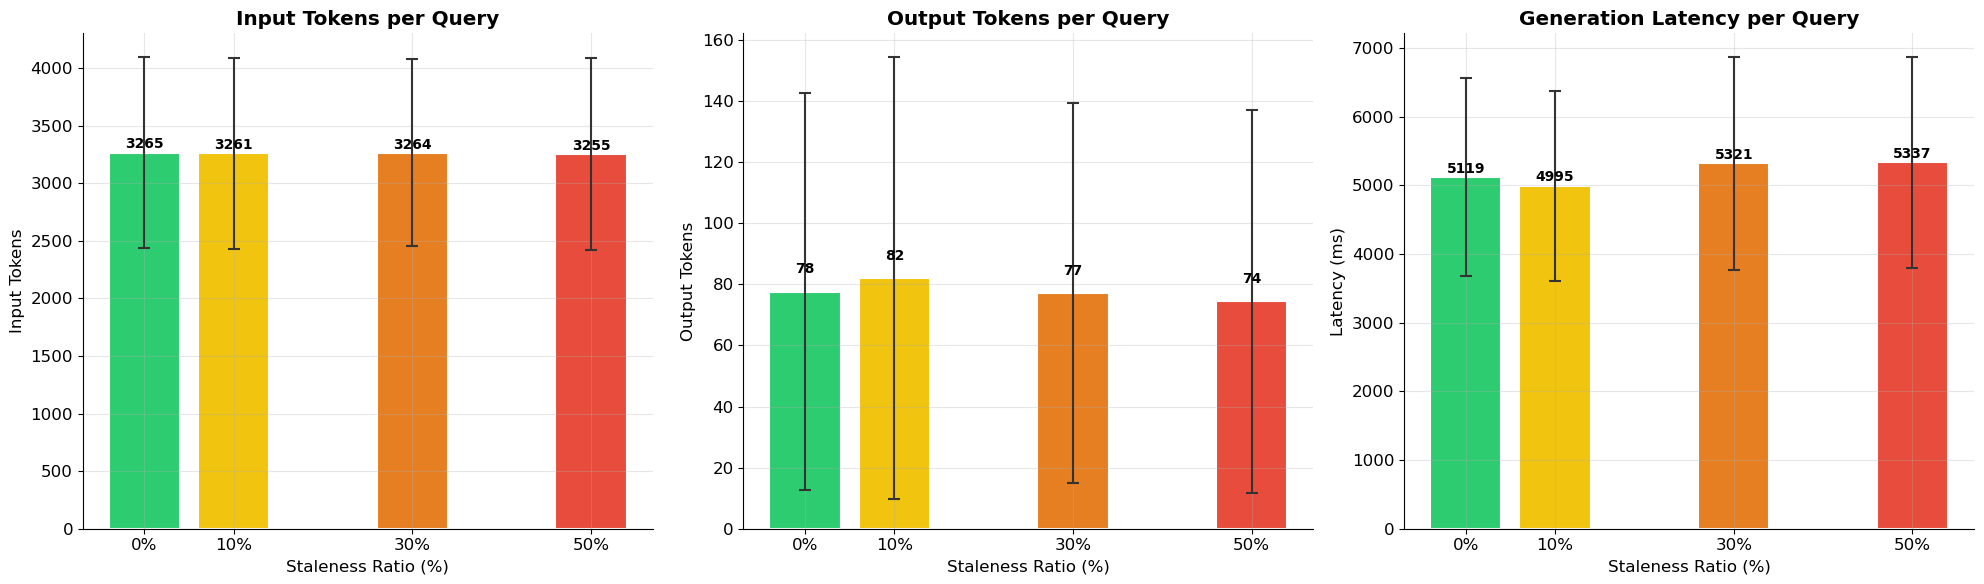

Saved: figures/fig25_generation_tokens_latency.png


In [6]:
# ── Fig 25: Input Tokens, Output Tokens, Latency ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = [COLORS[c] for c in CONDITIONS]

# Input tokens
ax = axes[0]
vals = [data['overall'][c]['input_tokens_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['input_tokens_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Input Tokens')
ax.set_title('Input Tokens per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Output tokens
ax = axes[1]
vals = [data['overall'][c]['output_tokens_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['output_tokens_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Output Tokens')
ax.set_title('Output Tokens per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Latency
ax = axes[2]
vals = [data['overall'][c]['latency_ms_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['latency_ms_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Latency (ms)')
ax.set_title('Generation Latency per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures_temporal/fig25_generation_tokens_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig25_generation_tokens_latency.png')

## 3. API Cost & Response Length
Does staleness increase generation cost and verbosity?

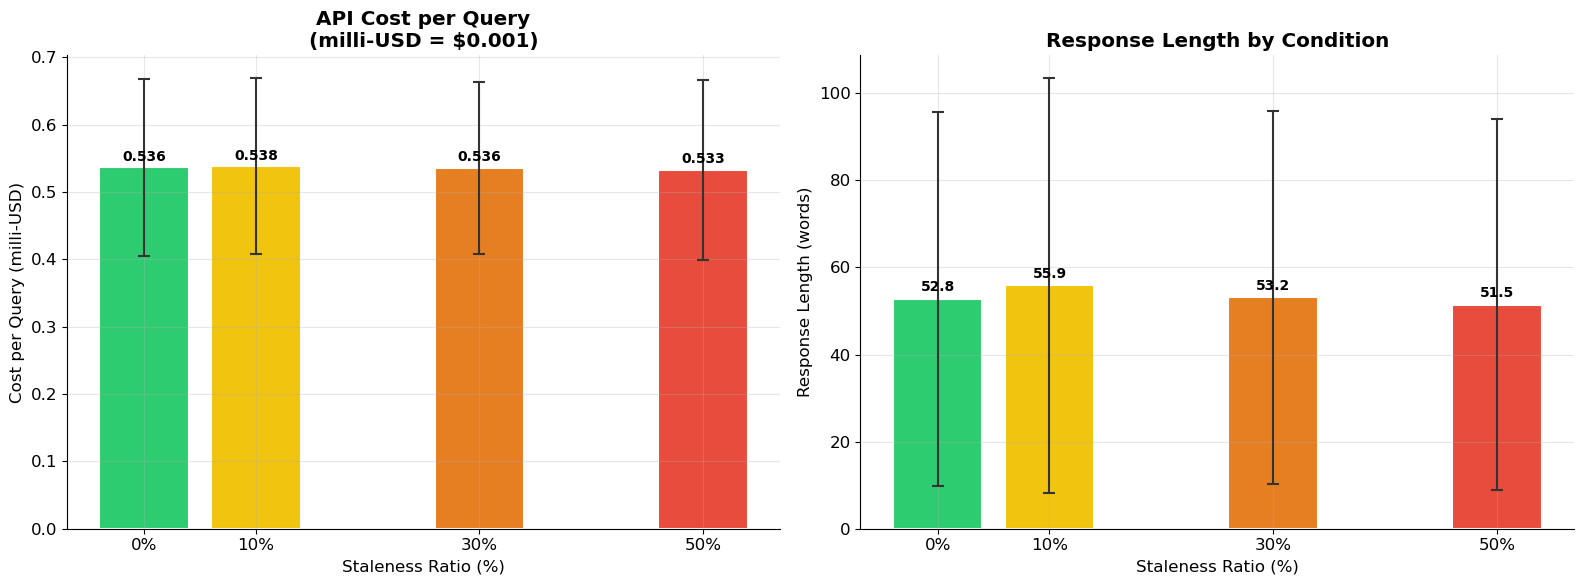

Saved: figures/fig26_generation_cost_length.png


In [7]:
# ── Fig 26: Cost & Response Length ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [COLORS[c] for c in CONDITIONS]

# API cost per query
ax = axes[0]
vals = [data['overall'][c]['cost_usd_mean'] * 1000 for c in CONDITIONS]  # show in milli-USD
stds = [data['overall'][c]['cost_usd_std'] * 1000 for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Cost per Query (milli-USD)')
ax.set_title('API Cost per Query\n(milli-USD = $0.001)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Response length (words)
ax = axes[1]
vals = [data['overall'][c]['response_length_words_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['response_length_words_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Response Length (words)')
ax.set_title('Response Length by Condition', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures_temporal/fig26_generation_cost_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig26_generation_cost_length.png')

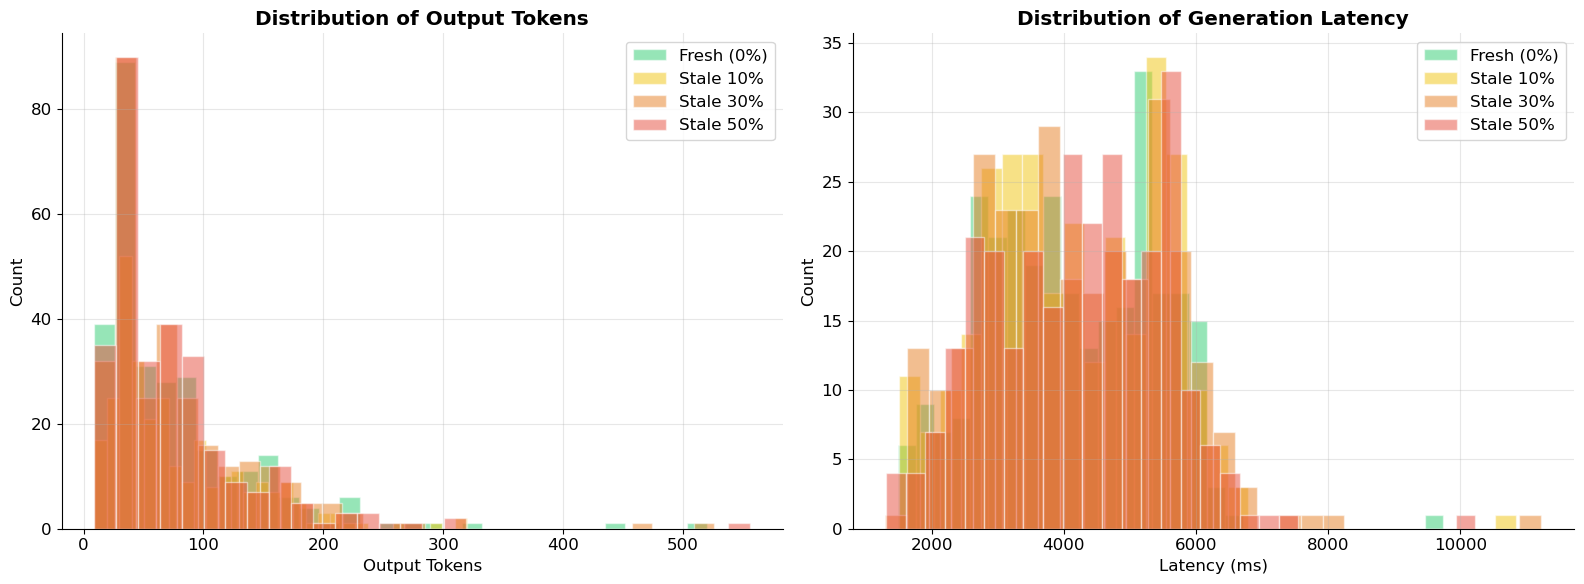

Saved: figures/fig27_generation_distributions.png


In [8]:
# ── Fig 27: Distributions of output tokens & latency ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]['output_tokens']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('Output Tokens')
ax.set_ylabel('Count')
ax.set_title('Distribution of Output Tokens', fontweight='bold')
ax.legend()

ax = axes[1]
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]['latency_ms']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Generation Latency', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../figures_temporal/fig27_generation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig27_generation_distributions.png')

## 3b. Answer Quality: Correctness & Hallucination
Does staleness degrade answer correctness and increase hallucination?

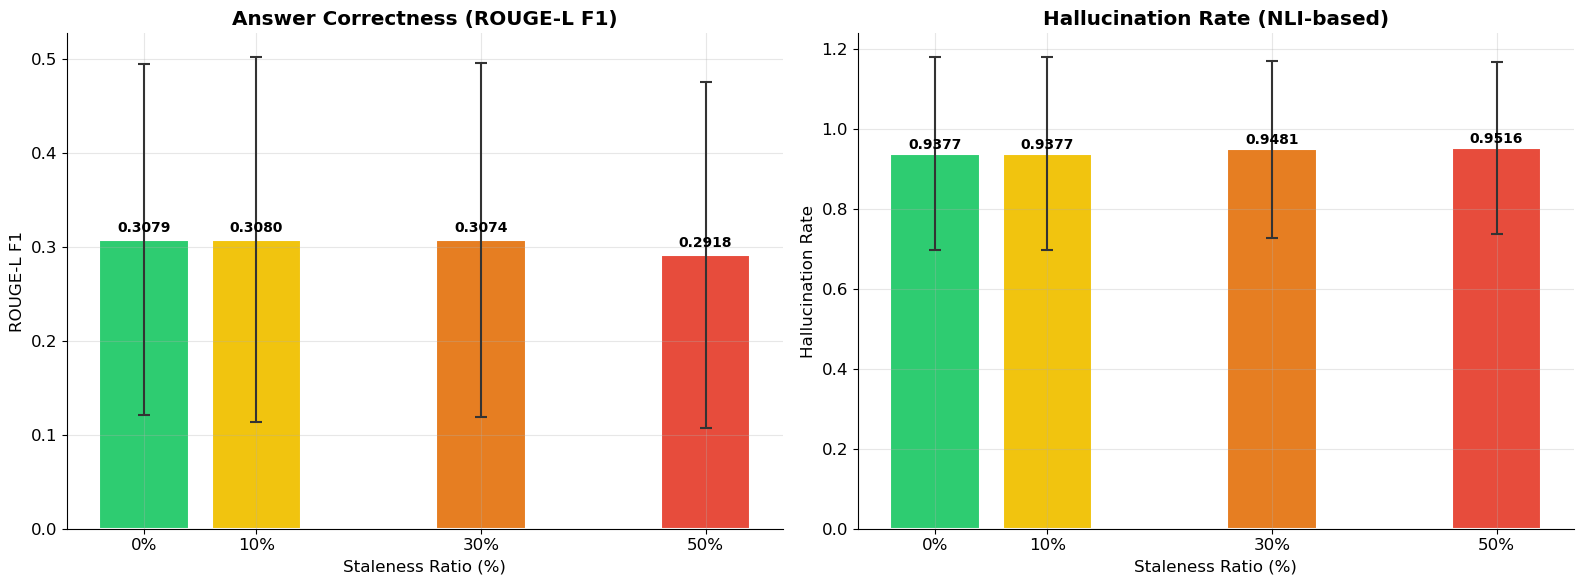

Saved: figures/fig27b_answer_quality.png


In [9]:
# ── Fig 27b: Answer Correctness & Hallucination Rate ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [COLORS[c] for c in CONDITIONS]

# Answer correctness (ROUGE-L F1)
ax = axes[0]
vals = [data['overall'][c]['answer_correctness_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['answer_correctness_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('ROUGE-L F1')
ax.set_title('Answer Correctness (ROUGE-L F1)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Hallucination rate
ax = axes[1]
vals = [data['overall'][c]['is_hallucination_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['is_hallucination_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Hallucination Rate')
ax.set_title('Hallucination Rate (NLI-based)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures_temporal/fig27b_answer_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig27b_answer_quality.png')

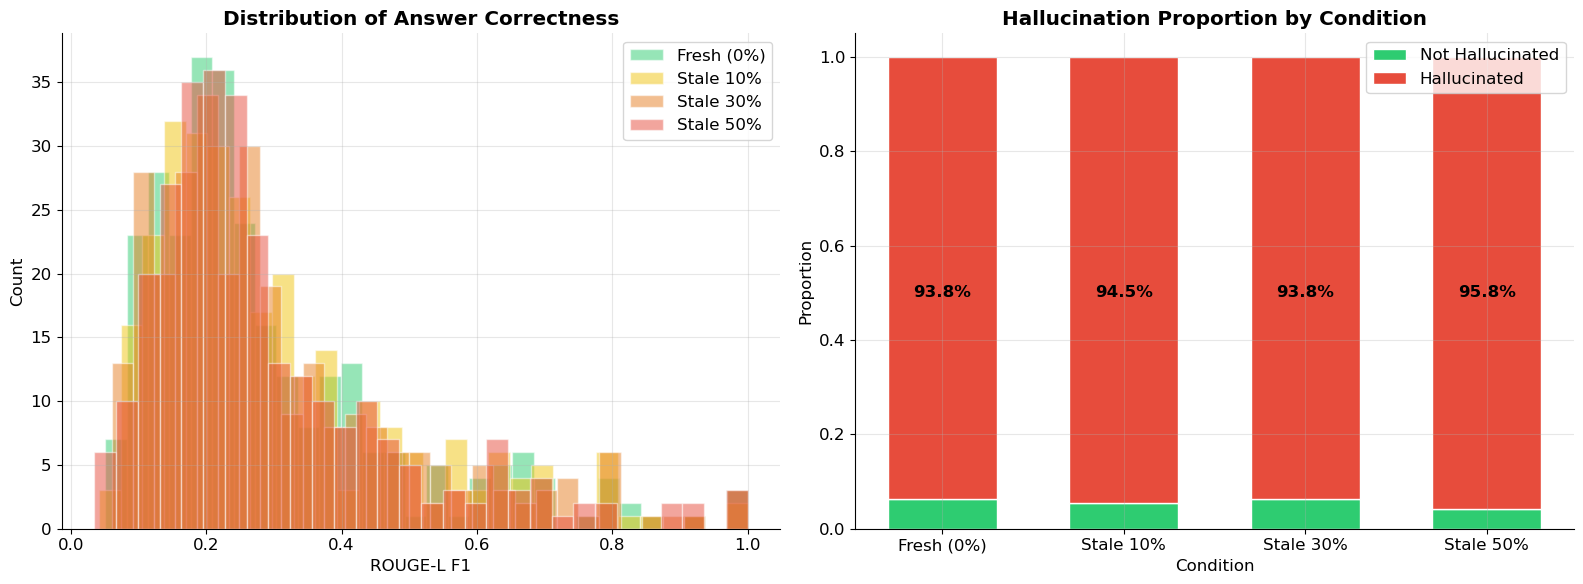

Saved: figures/fig27c_answer_quality_distributions.png


In [10]:
# ── Fig 27c: Distribution of answer correctness & hallucination proportion ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]['answer_correctness']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('ROUGE-L F1')
ax.set_ylabel('Count')
ax.set_title('Distribution of Answer Correctness', fontweight='bold')
ax.legend()

# Hallucination: stacked bar showing hallucinated vs not per condition
ax = axes[1]
x = np.arange(len(CONDITIONS))
hal_rates = [df[df['condition'] == c]['is_hallucination'].mean() for c in CONDITIONS]
non_hal = [1 - r for r in hal_rates]
bars1 = ax.bar(x, non_hal, 0.6, label='Not Hallucinated', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x, hal_rates, 0.6, bottom=non_hal, label='Hallucinated', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_title('Hallucination Proportion by Condition', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
for i, rate in enumerate(hal_rates):
    ax.text(i, 0.5, f'{rate:.1%}', ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures_temporal/fig27c_answer_quality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig27c_answer_quality_distributions.png')

## 4. Time-Sensitive vs. Time-Insensitive Comparison
Does generation behavior differ for time-sensitive queries under staleness?

In [11]:
# ── Build time-sensitivity dataframe ──
ts_rows = []
for cond in CONDITIONS:
    for ts_label, ts_key in [('Time-Sensitive', 'time_sensitive'), ('Time-Insensitive', 'time_insensitive')]:
        key = f'{cond}__{ts_key}'
        d = data['by_time_sensitivity'].get(key, {})
        if d:
            ts_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Query Type': ts_label,
                'Input Tokens': d.get('input_tokens_mean', 0),
                'Output Tokens': d.get('output_tokens_mean', 0),
                'Latency (ms)': d.get('latency_ms_mean', 0),
                'Response Words': d.get('response_length_words_mean', 0),
                'Cost/Query USD': d.get('cost_usd_mean', 0),
                'Answer Correctness': d.get('answer_correctness_mean', 0),
                'Hallucination Rate': d.get('is_hallucination_mean', 0),
            })

df_ts = pd.DataFrame(ts_rows)
print(df_ts.to_string(index=False, float_format='{:.4f}'.format))

 Condition  Staleness %       Query Type  Input Tokens  Output Tokens  Latency (ms)  Response Words  Cost/Query USD  Answer Correctness  Hallucination Rate
Fresh (0%)            0   Time-Sensitive     3243.5683        70.2518     4969.1572         48.3885          0.0005              0.3194              0.9209
Fresh (0%)            0 Time-Insensitive     3285.3333        84.4000     5258.1434         56.9800          0.0005              0.2973              0.9533
 Stale 10%           10   Time-Sensitive     3236.5180        78.6691     4932.1208         53.9568          0.0005              0.3207              0.9353
 Stale 10%           10 Time-Insensitive     3283.8067        85.1733     5053.3666         57.6400          0.0005              0.2963              0.9400
 Stale 30%           30   Time-Sensitive     3244.4820        65.6115     5205.7328         46.2662          0.0005              0.3208              0.9496
 Stale 30%           30 Time-Insensitive     3281.7800        87

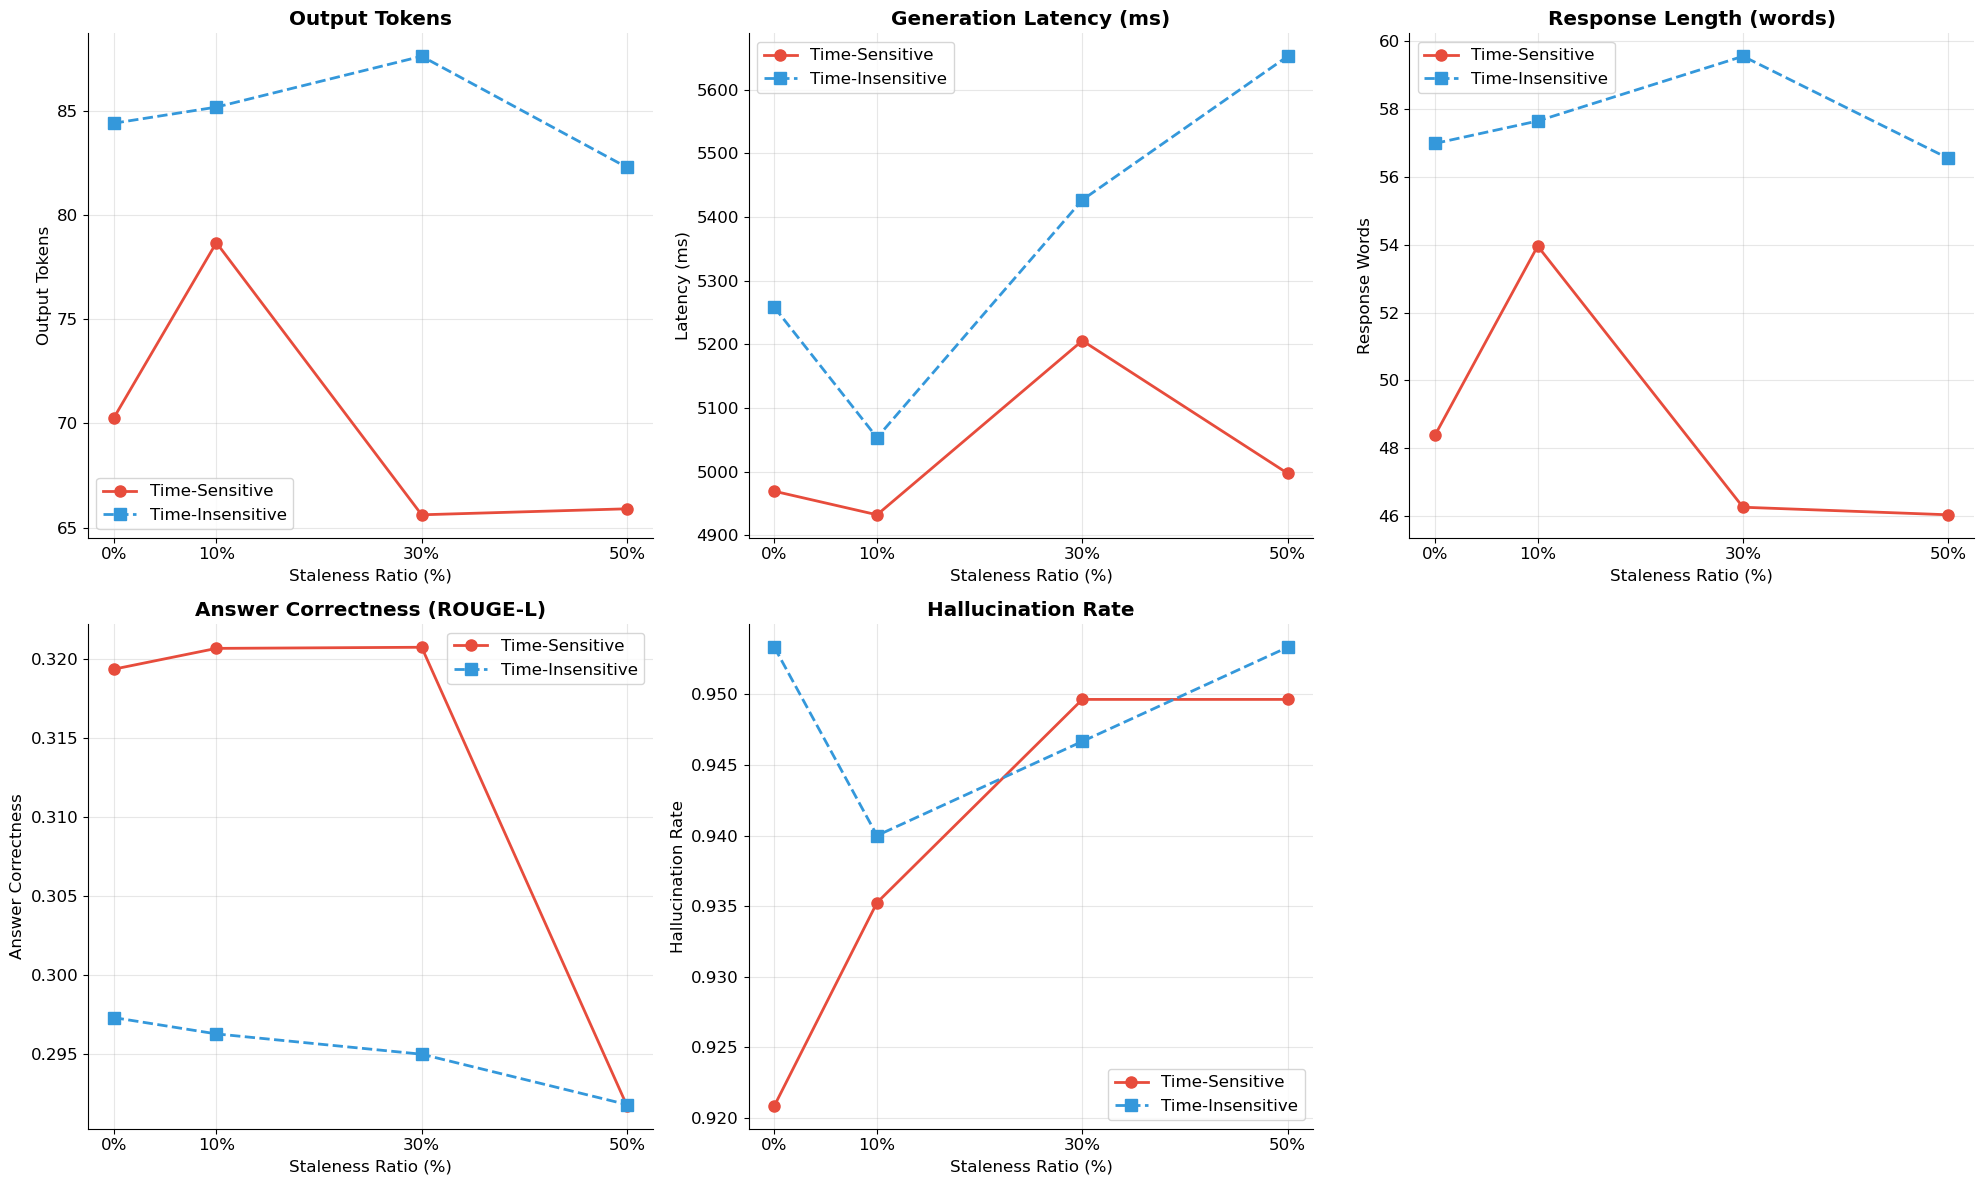

Saved: figures/fig28_generation_time_sensitivity.png


In [12]:
# ── Fig 28: Time-sensitivity comparison ──
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

metric_configs = [
    ('Output Tokens', 'Output Tokens'),
    ('Latency (ms)', 'Generation Latency (ms)'),
    ('Response Words', 'Response Length (words)'),
    ('Answer Correctness', 'Answer Correctness (ROUGE-L)'),
    ('Hallucination Rate', 'Hallucination Rate'),
]

for idx, (col, title) in enumerate(metric_configs):
    ax = axes[idx // 3][idx % 3]
    for qt, style in [('Time-Sensitive', '-o'), ('Time-Insensitive', '--s')]:
        subset = df_ts[df_ts['Query Type'] == qt]
        color = '#e74c3c' if qt == 'Time-Sensitive' else '#3498db'
        ax.plot(subset['Staleness %'], subset[col], style,
                label=qt, color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(col)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend()

# Hide unused subplot
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('../figures_temporal/fig28_generation_time_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig28_generation_time_sensitivity.png')

## 5. Domain-Level Analysis
Which domains see the most generation overhead from staleness?

In [13]:
# ── Build domain dataframe ──
domain_rows = []
for cond in CONDITIONS:
    for domain in DOMAINS:
        key = f'{cond}__{domain}'
        d = data['by_domain'].get(key, {})
        if d:
            domain_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Domain': DOMAIN_LABELS.get(domain, domain),
                'domain_key': domain,
                'Output Tokens': d.get('output_tokens_mean', 0),
                'Latency (ms)': d.get('latency_ms_mean', 0),
                'Response Words': d.get('response_length_words_mean', 0),
                'Cost/Query USD': d.get('cost_usd_mean', 0),
                'Answer Correctness': d.get('answer_correctness_mean', 0),
                'Hallucination Rate': d.get('is_hallucination_mean', 0),
                'n': d.get('n', 0),
            })

df_domain = pd.DataFrame(domain_rows)

# Pivot: answer correctness by domain x condition
pivot = df_domain.pivot_table(index='Domain', columns='Condition', values='Answer Correctness')
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITIONS]]
print('Answer Correctness (ROUGE-L F1) by Domain x Condition:')
print(pivot.to_string(float_format='{:.4f}'.format))
print()

pivot2 = df_domain.pivot_table(index='Domain', columns='Condition', values='Hallucination Rate')
pivot2 = pivot2[[CONDITION_LABELS[c] for c in CONDITIONS]]
print('Hallucination Rate by Domain x Condition:')
print(pivot2.to_string(float_format='{:.4f}'.format))

Answer Correctness (ROUGE-L F1) by Domain x Condition:
Condition            Fresh (0%)  Stale 10%  Stale 30%  Stale 50%
Domain                                                          
Expert/Cross-domain      0.2289     0.2373     0.2366     0.2233
Finance                  0.4204     0.4512     0.4279     0.3883
Healthcare               0.3921     0.3540     0.3941     0.3622
Legal                    0.1990     0.2012     0.1882     0.1799
SaaS/IT                  0.2897     0.2859     0.2797     0.2960

Hallucination Rate by Domain x Condition:
Condition            Fresh (0%)  Stale 10%  Stale 30%  Stale 50%
Domain                                                          
Expert/Cross-domain      0.9483     0.9828     0.9828     1.0000
Finance                  0.8833     0.8667     0.9000     0.8667
Healthcare               0.9138     0.9483     0.9655     0.9655
Legal                    1.0000     0.9818     0.9636     0.9818
SaaS/IT                  0.9483     0.9138     0.9310    

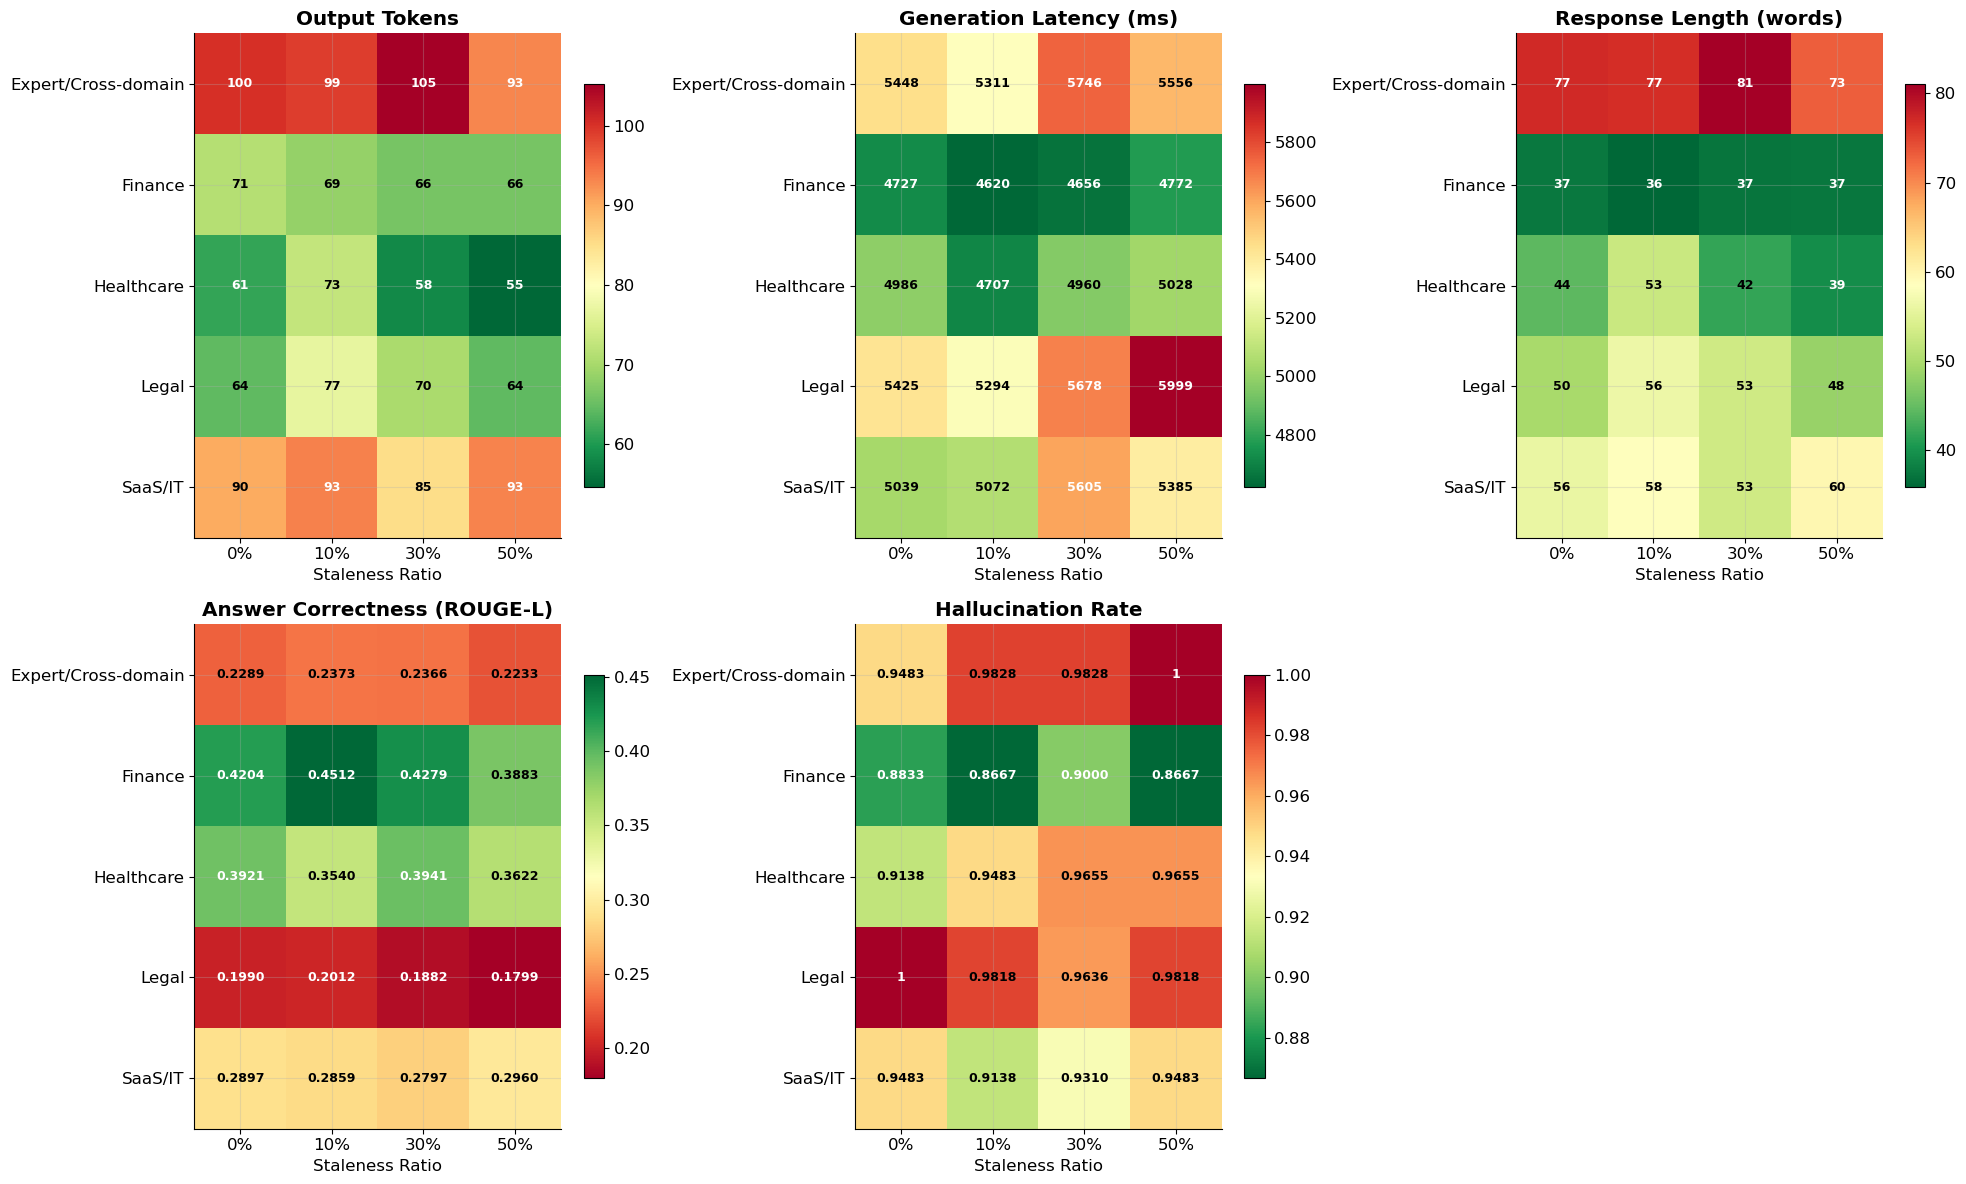

Saved: figures/fig29_generation_domain_heatmap.png


In [14]:
# ── Fig 29: Domain heatmaps ──
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

domain_metrics = [
    ('Output Tokens', 'Output Tokens', 'RdYlGn_r'),
    ('Latency (ms)', 'Generation Latency (ms)', 'RdYlGn_r'),
    ('Response Words', 'Response Length (words)', 'RdYlGn_r'),
    ('Answer Correctness', 'Answer Correctness (ROUGE-L)', 'RdYlGn'),
    ('Hallucination Rate', 'Hallucination Rate', 'RdYlGn_r'),
]

for idx, (metric, title, cmap) in enumerate(domain_metrics):
    ax = axes[idx // 3][idx % 3]
    pivot = df_domain.pivot_table(index='Domain', columns='Staleness %', values=metric)
    pivot = pivot[[0, 10, 30, 50]]

    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Staleness Ratio')
    ax.set_title(title, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(4):
            val = pivot.values[i, j]
            fmt = f'{val:.4f}' if val < 1 else f'{val:.0f}'
            text_color = 'white' if abs(val - pivot.values.mean()) > pivot.values.std() else 'black'
            ax.text(j, i, fmt, ha='center', va='center',
                    fontsize=9, fontweight='bold', color=text_color)

    plt.colorbar(im, ax=ax, shrink=0.8)

# Hide unused subplot
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('../figures_temporal/fig29_generation_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig29_generation_domain_heatmap.png')

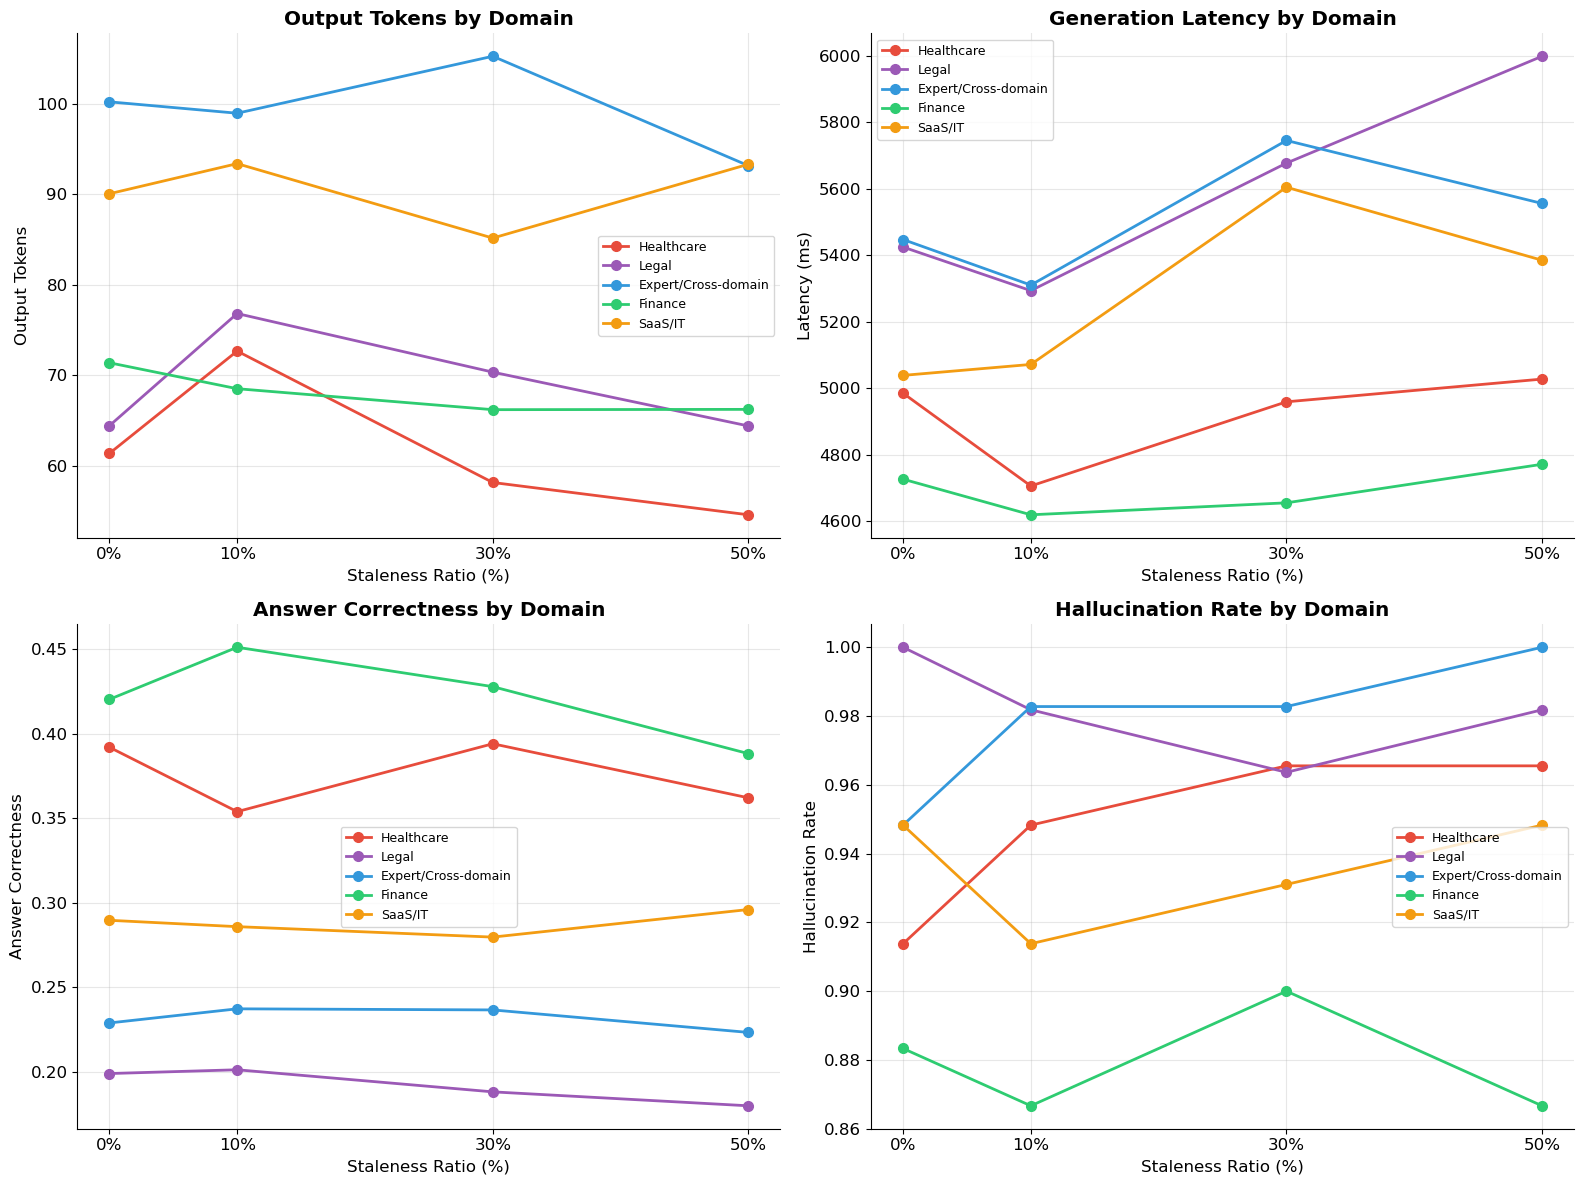

Saved: figures/fig30_generation_domain_curves.png


In [15]:
# ── Fig 30: Domain degradation curves ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

domain_colors = {
    'Healthcare': '#e74c3c',
    'Legal': '#9b59b6',
    'Expert/Cross-domain': '#3498db',
    'Finance': '#2ecc71',
    'SaaS/IT': '#f39c12',
}

curve_metrics = [
    ('Output Tokens', 'Output Tokens by Domain'),
    ('Latency (ms)', 'Generation Latency by Domain'),
    ('Answer Correctness', 'Answer Correctness by Domain'),
    ('Hallucination Rate', 'Hallucination Rate by Domain'),
]

for ax, (metric, title) in zip(axes.flat, curve_metrics):
    for domain_label in DOMAIN_LABELS.values():
        subset = df_domain[df_domain['Domain'] == domain_label]
        ax.plot(subset['Staleness %'], subset[metric], '-o',
                label=domain_label, color=domain_colors.get(domain_label, '#333'),
                linewidth=2, markersize=7)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures_temporal/fig30_generation_domain_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig30_generation_domain_curves.png')

## 6. Context Quality vs. Generation Behavior
Do upstream context quality signals (contradiction density, redundancy, stale token ratio) correlate with generation output?

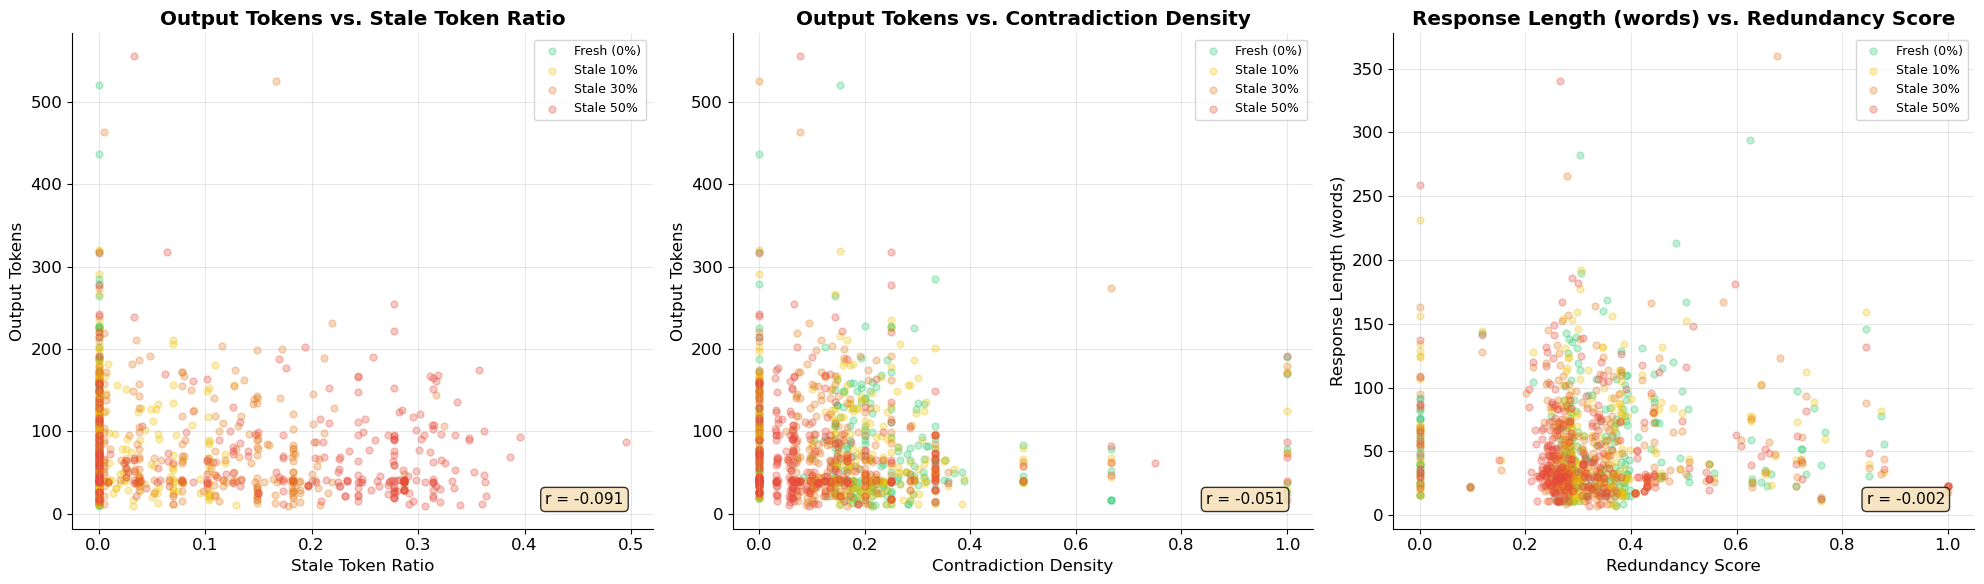

Saved: figures/fig31_context_vs_generation.png


In [16]:
# ── Fig 31: Context quality vs generation output (scatter) ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scatter_configs = [
    ('stale_token_ratio', 'output_tokens', 'Stale Token Ratio', 'Output Tokens'),
    ('contradiction_density', 'output_tokens', 'Contradiction Density', 'Output Tokens'),
    ('redundancy_score', 'response_length_words', 'Redundancy Score', 'Response Length (words)'),
]

for ax, (x_col, y_col, x_label, y_label) in zip(axes, scatter_configs):
    for cond in CONDITIONS:
        subset = df[df['condition'] == cond]
        ax.scatter(subset[x_col], subset[y_col],
                   alpha=0.3, s=25, color=COLORS[cond], label=CONDITION_LABELS[cond])

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{y_label} vs. {x_label}', fontweight='bold')
    ax.legend(fontsize=9)

    # Correlation across all data
    x_vals = df[x_col].values
    y_vals = df[y_col].values
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    if mask.sum() > 10:
        corr = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
        ax.text(0.95, 0.05, f'r = {corr:.3f}',
                transform=ax.transAxes, ha='right', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../figures_temporal/fig31_context_vs_generation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig31_context_vs_generation.png')

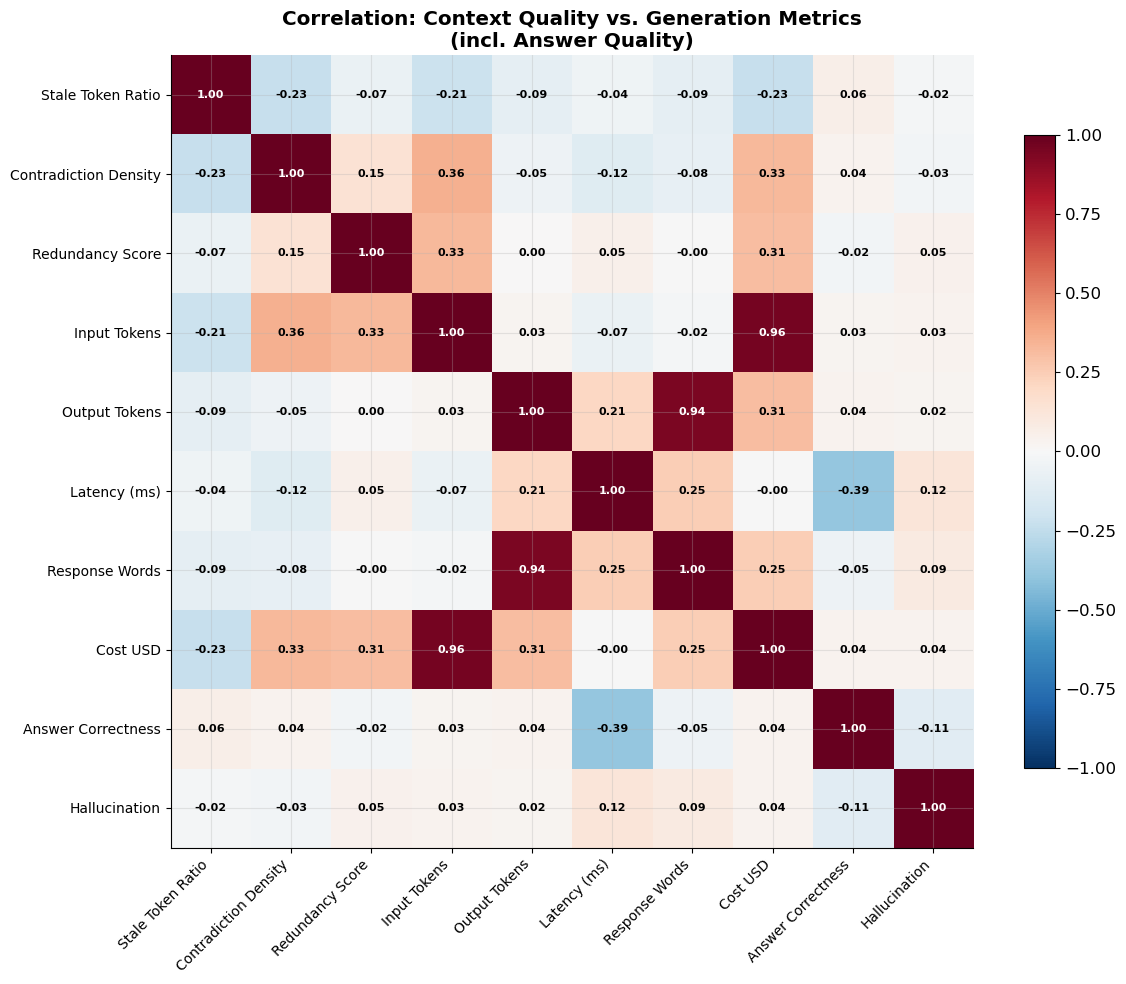

Saved: figures/fig32_correlation_matrix.png


In [17]:
# ── Correlation matrix between context quality and generation metrics ──
corr_cols = ['stale_token_ratio', 'contradiction_density', 'redundancy_score',
             'input_tokens', 'output_tokens', 'latency_ms', 'response_length_words',
             'cost_usd', 'answer_correctness', 'is_hallucination']
corr_labels = ['Stale Token Ratio', 'Contradiction Density', 'Redundancy Score',
               'Input Tokens', 'Output Tokens', 'Latency (ms)', 'Response Words',
               'Cost USD', 'Answer Correctness', 'Hallucination']

corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr_labels)))
ax.set_yticklabels(corr_labels, fontsize=10)
ax.set_title('Correlation: Context Quality vs. Generation Metrics\n(incl. Answer Quality)', fontweight='bold')

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_matrix.values[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('../figures_temporal/fig32_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig32_correlation_matrix.png')

## 7. Cumulative Cost Analysis
Total API cost across all conditions and projected scaling.

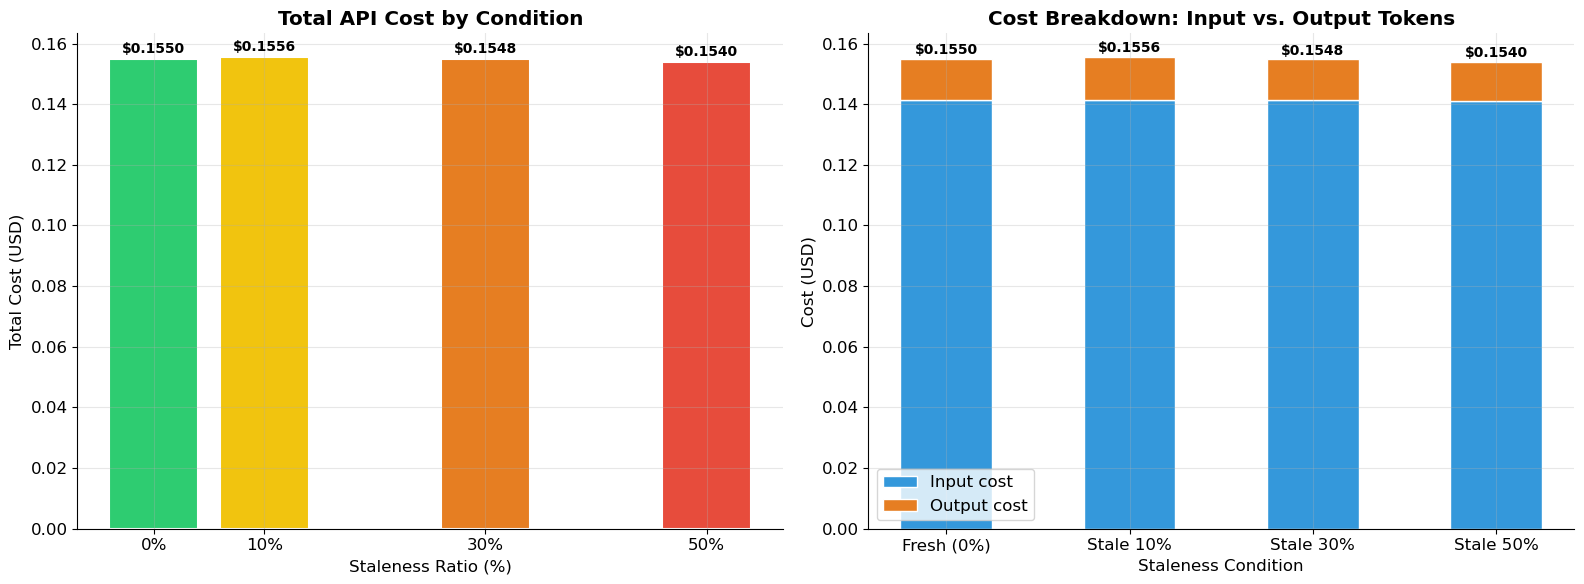

Saved: figures/fig33_generation_cost_breakdown.png


In [18]:
# ── Fig 33: Cumulative cost ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [COLORS[c] for c in CONDITIONS]

# Total cost per condition
ax = axes[0]
total_costs = [data['overall'][c]['cost_usd_sum'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, total_costs, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Total Cost (USD)')
ax.set_title('Total API Cost by Condition', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, total_costs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'${val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Cost breakdown: input vs output
ax = axes[1]
# Estimate input/output cost split from token counts and pricing
model_prices = {
    'gemini-2.5-flash': {'input': 0.15, 'output': 0.60},
    'gemini-2.0-flash': {'input': 0.10, 'output': 0.40},
    'gemini-1.5-flash': {'input': 0.075, 'output': 0.30},
}
prices = model_prices.get(model_name, model_prices['gemini-2.5-flash'])

x = np.arange(len(CONDITIONS))
width = 0.5
input_costs = [data['overall'][c]['input_tokens_sum'] * prices['input'] / 1e6 for c in CONDITIONS]
output_costs = [data['overall'][c]['output_tokens_sum'] * prices['output'] / 1e6 for c in CONDITIONS]

bars1 = ax.bar(x, input_costs, width, label='Input cost', color='#3498db', edgecolor='white')
bars2 = ax.bar(x, output_costs, width, bottom=input_costs, label='Output cost', color='#e67e22', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost Breakdown: Input vs. Output Tokens', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()

for i, (ic, oc) in enumerate(zip(input_costs, output_costs)):
    ax.text(i, ic + oc + 0.0005, f'${ic+oc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures_temporal/fig33_generation_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig33_generation_cost_breakdown.png')

## 8. Summary Statistics

In [19]:
# ── Key findings ──
print('=' * 60)
print(f'KEY FINDINGS — GENERATION STAGE (model={model_name})')
print('=' * 60)

print(f'\n1. INPUT TOKENS')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["input_tokens_mean"]:.1f} '
          f'+/- {d["input_tokens_std"]:.1f}')

print(f'\n2. OUTPUT TOKENS')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["output_tokens_mean"]:.1f} '
          f'+/- {d["output_tokens_std"]:.1f}')

print(f'\n3. GENERATION LATENCY (ms)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["latency_ms_mean"]:.1f} '
          f'+/- {d["latency_ms_std"]:.1f}')

print(f'\n4. RESPONSE LENGTH (words)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["response_length_words_mean"]:.1f} '
          f'+/- {d["response_length_words_std"]:.1f}')

print(f'\n5. ANSWER CORRECTNESS (ROUGE-L F1)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["answer_correctness_mean"]:.4f} '
          f'+/- {d["answer_correctness_std"]:.4f}')

print(f'\n6. HALLUCINATION RATE')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["is_hallucination_mean"]:.4f} '
          f'+/- {d["is_hallucination_std"]:.4f} '
          f'({d["is_hallucination_sum"]:.0f}/{d["n"]} queries)')

print(f'\n7. API COST')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: ${d["cost_usd_mean"]:.6f}/query '
          f'(total: ${d["cost_usd_sum"]:.4f})')

grand_total = sum(data['overall'][c]['cost_usd_sum'] for c in CONDITIONS)
print(f'\n   Grand total across all conditions: ${grand_total:.4f}')

# Delta analysis: fresh vs stale_50
print(f'\n8. FRESH vs. STALE-50% DELTA')
fresh = data['overall']['fresh']
stale50 = data['overall']['stale_50']
for label, key in [
    ('Output tokens', 'output_tokens_mean'),
    ('Latency (ms)', 'latency_ms_mean'),
    ('Response words', 'response_length_words_mean'),
    ('Answer correctness', 'answer_correctness_mean'),
    ('Hallucination rate', 'is_hallucination_mean'),
    ('Cost/query USD', 'cost_usd_mean'),
]:
    f_val = fresh[key]
    s_val = stale50[key]
    delta = s_val - f_val
    pct = delta / f_val * 100 if f_val > 0 else float('inf')
    print(f'   {label:<20}: {f_val:.4f} -> {s_val:.4f} ({delta:+.4f}, {pct:+.1f}%)')

KEY FINDINGS — GENERATION STAGE (model=gemini-2.5-flash)

1. INPUT TOKENS
     Fresh (0%): 3265.2 +/- 831.1
      Stale 10%: 3261.1 +/- 829.4
      Stale 30%: 3263.8 +/- 812.8
      Stale 50%: 3255.0 +/- 836.4

2. OUTPUT TOKENS
     Fresh (0%): 77.6 +/- 65.0
      Stale 10%: 82.0 +/- 72.4
      Stale 30%: 77.0 +/- 62.2
      Stale 50%: 74.4 +/- 62.7

3. GENERATION LATENCY (ms)
     Fresh (0%): 5119.2 +/- 1443.0
      Stale 10%: 4995.1 +/- 1382.9
      Stale 30%: 5320.5 +/- 1548.5
      Stale 50%: 5337.4 +/- 1533.7

4. RESPONSE LENGTH (words)
     Fresh (0%): 52.8 +/- 43.0
      Stale 10%: 55.9 +/- 47.7
      Stale 30%: 53.2 +/- 42.8
      Stale 50%: 51.5 +/- 42.6

5. ANSWER CORRECTNESS (ROUGE-L F1)
     Fresh (0%): 0.3079 +/- 0.1867
      Stale 10%: 0.3080 +/- 0.1945
      Stale 30%: 0.3074 +/- 0.1883
      Stale 50%: 0.2918 +/- 0.1843

6. HALLUCINATION RATE
     Fresh (0%): 0.9377 +/- 0.2417 (271/289 queries)
      Stale 10%: 0.9377 +/- 0.2417 (271/289 queries)
      Stale 30%: 0.9481

In [20]:
# ── Export summary table ──
summary_df = df_overview[['Staleness %', 'Input Tokens (mean)', 'Output Tokens (mean)',
                           'Latency ms (mean)', 'Response Words (mean)',
                           'Answer Correctness', 'Hallucination Rate',
                           'Cost/Query USD (mean)', 'Total Cost USD']].copy()
summary_df.to_csv('../results/generation_temporal_summary_table.csv')
print('Exported: results/generation_summary_table.csv')
print()
print(summary_df.to_string(float_format='{:.4f}'.format))

Exported: results/generation_summary_table.csv

            Staleness %  Input Tokens (mean)  Output Tokens (mean)  Latency ms (mean)  Response Words (mean)  Answer Correctness  Hallucination Rate  Cost/Query USD (mean)  Total Cost USD
Condition                                                                                                                                                                                  
Fresh (0%)            0            3265.2457               77.5952          5119.1501                52.8478              0.3079              0.9377                 0.0005          0.1550
Stale 10%            10            3261.0623               82.0450          4995.0511                55.8685              0.3080              0.9377                 0.0005          0.1556
Stale 30%            30            3263.8408               77.0311          5320.5332                53.1592              0.3074              0.9481                 0.0005          0.1548
Stale 50%   

## 9. Findings and Results

Key questions to answer:

- **Does staleness increase output verbosity?** If the LLM receives conflicting context, it may hedge or qualify its answer, producing more output tokens and higher cost.
- **Latency impact:** Does generation take longer when context contains stale/contradictory information? This could indicate the model "struggles" with conflicting evidence.
- **Cost scaling:** How does per-query cost change with staleness? At scale (thousands of queries), even small per-query increases compound.
- **Answer correctness:** Does ROUGE-L F1 against ground truth degrade as staleness increases? This directly measures whether stale context leads to worse answers.
- **Hallucination rate:** Does NLI-based hallucination detection flag more answers as staleness increases? This captures whether the model fabricates information when context is contradictory.
- **Time-sensitive gap:** Do time-sensitive queries show a larger generation overhead under staleness than time-insensitive ones?
- **Domain variation:** Which enterprise domains are most affected by staleness at the generation stage?
- **Upstream correlation:** Do context assembly metrics (contradiction density, redundancy, stale token ratio) predict generation behavior and answer quality?